# Clasificación de gestos de mano mediante señales EMG utilizando redes LSTM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
import glob
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import mean_absolute_error
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shutil
import hashlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
baseDir = "/content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG"

datasetPath = os.path.join(baseDir, "Dataset")
modelsDir   = os.path.join(baseDir, "Models", "Train models")
scalersDir  = os.path.join(baseDir, "Scalers")

modelPath  = os.path.join(modelsDir, "EMGBiLSTMModel4.pt")
scalerPath = os.path.join(scalersDir, "scaler4.save")

trainingCurvesPath = os.path.join(baseDir, "training_curves4.npz")

print("datasetPath:", datasetPath)
print("modelPath:", modelPath)
print("scalerPath:", scalerPath)
print("trainingCurvesPath:", trainingCurvesPath)

datasetPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Dataset
modelPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGBiLSTMModel4.pt
scalerPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Scalers/scaler4.save
trainingCurvesPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/training_curves4.npz


In [ ]:
txtFiles = sorted(glob.glob(os.path.join(datasetPath, "**/*.txt"), recursive=True))
print(f"Archivos encontrados: {len(txtFiles)}")

Archivos encontrados: 82


In [ ]:
dfChannels = [f'ch{i}' for i in range(1, 9)]

def loadFile(filePath):
    try:
        dfRaw = pd.read_csv(
            filePath,
            sep=r"\s+",
            engine="python",
            header=None,
            on_bad_lines='skip'
        )

        if dfRaw.shape[1] != 10:
            print(f"Archivo con columnas inesperadas: {filePath} : {dfRaw.shape[1]} columnas")
            return pd.DataFrame()

        dfRaw.columns = ['time'] + [f'ch{i}' for i in range(1, 9)] + ['label']

        dfRaw = dfRaw.apply(pd.to_numeric, errors='coerce')
        dfRaw = dfRaw.dropna().reset_index(drop=True)

        dfRaw = dfRaw[dfRaw['label'] != 0].reset_index(drop=True)

        dfRaw["source_file"] = filePath

        return dfRaw

    except Exception as e:
        print(f"Error al leer {filePath}: {e}")
        return pd.DataFrame()


txtFiles = sorted(glob.glob(os.path.join(datasetPath, "**/*.txt"), recursive=True))
print(f"Archivos encontrados: {len(txtFiles)}")

fileDfs = []
for f in txtFiles:
    df = loadFile(f)
    if not df.empty:
        fileDfs.append(df)

print(f"Archivos válidos cargados: {len(fileDfs)}")

Archivos encontrados: 82
Archivo con columnas inesperadas: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Dataset/README.txt : 3 columnas
Archivos válidos cargados: 81


In [ ]:
def createSlidingWindowsFromFiles(fileDfs, channels, windowSize=200, stepSize=100):
    X, y, windowFiles = [], [], []

    for df in fileDfs:
        if len(df) < windowSize:
            continue

        source_file = df["source_file"].iloc[0]
        dataArray = df[channels + ['label']].values
        totalLen = len(dataArray)

        for start in range(0, totalLen - windowSize + 1, stepSize):
            end = start + windowSize
            window = dataArray[start:end]

            segment = window[:, :-1]
            labels = window[:, -1]

            if np.all(labels == labels[0]):
                X.append(segment)
                y.append(int(labels[0]))
                windowFiles.append(source_file)

    return np.array(X), np.array(y), np.array(windowFiles)


windowSize = 200
stepSize = 100

xDataRaw, yDataRaw, windowFiles = createSlidingWindowsFromFiles(
    fileDfs,
    dfChannels,
    windowSize=windowSize,
    stepSize=stepSize
)

print("X raw shape:", xDataRaw.shape)
print("y raw shape:", yDataRaw.shape)
print("Clases originales:", np.unique(yDataRaw, return_counts=True))
print("Archivos con ventanas:", len(np.unique(windowFiles)))

X raw shape: (15039, 200, 8)
y raw shape: (15039,)
Clases originales: (array([1, 2, 3, 4, 5, 6, 7]), array([2526, 2407, 2458, 2494, 2499, 2504,  151]))
Archivos con ventanas: 81


In [ ]:
originalLabels = sorted(np.unique(yDataRaw))
labelToIndex = {label: idx for idx, label in enumerate(originalLabels)}
indexToLabel = {idx: label for label, idx in labelToIndex.items()}

yDataEncoded = np.array([labelToIndex[label] for label in yDataRaw])

numClasses = len(originalLabels)

print("Etiquetas originales:", originalLabels)
print("Mapeo label -> índice:", labelToIndex)
print("Número de clases:", numClasses)
print("Distribución codificada:", np.unique(yDataEncoded, return_counts=True))

Etiquetas originales: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Mapeo label -> índice: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5, np.int64(7): 6}
Número de clases: 7
Distribución codificada: (array([0, 1, 2, 3, 4, 5, 6]), array([2526, 2407, 2458, 2494, 2499, 2504,  151]))


In [ ]:
uniqueFiles = np.unique(windowFiles)

def has_all_classes(y, numClasses):
    present = set(np.unique(y))
    expected = set(range(numClasses))
    return expected.issubset(present)

def print_split_distribution_simple(name, y, indexToLabel, numClasses):
    print(f"\n===== {name} =====")
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip(unique, counts))

    for idx in range(numClasses):
        original_label = indexToLabel[idx]
        count = dist.get(idx, 0)
        print(f"Clase interna {idx} / label original {original_label}: {count}")

best_split = None

for seed in range(0, 500):
    trainFiles, testValFiles = train_test_split(
        uniqueFiles,
        test_size=0.2,
        random_state=seed
    )

    valFiles, testFiles = train_test_split(
        testValFiles,
        test_size=0.5,
        random_state=seed
    )

    trainMask = np.isin(windowFiles, trainFiles)
    valMask   = np.isin(windowFiles, valFiles)
    testMask  = np.isin(windowFiles, testFiles)

    yTrainCandidate = yDataEncoded[trainMask]
    yValCandidate   = yDataEncoded[valMask]
    yTestCandidate  = yDataEncoded[testMask]

    if (
        has_all_classes(yTrainCandidate, numClasses)
        and has_all_classes(yValCandidate, numClasses)
        and has_all_classes(yTestCandidate, numClasses)
    ):
        best_split = {
            "seed": seed,
            "trainMask": trainMask,
            "valMask": valMask,
            "testMask": testMask
        }
        print(f"Split válido encontrado con random_state={seed}")
        break

if best_split is None:
    raise ValueError(
        "No se encontró un split por archivo donde todas las clases aparezcan en train, val y test. "
        "Probablemente la clase 7 está concentrada en muy pocos archivos."
    )

trainMask = best_split["trainMask"]
valMask   = best_split["valMask"]
testMask  = best_split["testMask"]

xTrainRaw = xDataRaw[trainMask]
yTrain    = yDataEncoded[trainMask]

xValRaw = xDataRaw[valMask]
yVal    = yDataEncoded[valMask]

xTestRaw = xDataRaw[testMask]
yTest    = yDataEncoded[testMask]

print("Train:", xTrainRaw.shape, yTrain.shape)
print("Val:", xValRaw.shape, yVal.shape)
print("Test:", xTestRaw.shape, yTest.shape)

print_split_distribution_simple("TRAIN", yTrain, indexToLabel, numClasses)
print_split_distribution_simple("VAL", yVal, indexToLabel, numClasses)
print_split_distribution_simple("TEST", yTest, indexToLabel, numClasses)

Split válido encontrado con random_state=15
Train: (11851, 200, 8) (11851,)
Val: (1480, 200, 8) (1480,)
Test: (1708, 200, 8) (1708,)

===== TRAIN =====
Clase interna 0 / label original 1: 2006
Clase interna 1 / label original 2: 1902
Clase interna 2 / label original 3: 1942
Clase interna 3 / label original 4: 1960
Clase interna 4 / label original 5: 1979
Clase interna 5 / label original 6: 1972
Clase interna 6 / label original 7: 90

===== VAL =====
Clase interna 0 / label original 1: 259
Clase interna 1 / label original 2: 236
Clase interna 2 / label original 3: 230
Clase interna 3 / label original 4: 244
Clase interna 4 / label original 5: 239
Clase interna 5 / label original 6: 239
Clase interna 6 / label original 7: 33

===== TEST =====
Clase interna 0 / label original 1: 261
Clase interna 1 / label original 2: 269
Clase interna 2 / label original 3: 286
Clase interna 3 / label original 4: 290
Clase interna 4 / label original 5: 281
Clase interna 5 / label original 6: 293
Clase int

In [ ]:
scaler = StandardScaler()

xTrainFlat = xTrainRaw.reshape(-1, xTrainRaw.shape[-1])
scaler.fit(xTrainFlat)

def scaleWindows(X, scaler):
    originalShape = X.shape
    XFlat = X.reshape(-1, originalShape[-1])
    XScaled = scaler.transform(XFlat)
    return XScaled.reshape(originalShape)

xTrain = scaleWindows(xTrainRaw, scaler)
xVal   = scaleWindows(xValRaw, scaler)
xTest  = scaleWindows(xTestRaw, scaler)

print("Media aproximada train:", xTrain.reshape(-1, xTrain.shape[-1]).mean(axis=0))
print("Std aproximada train:", xTrain.reshape(-1, xTrain.shape[-1]).std(axis=0))

Media aproximada train: [-1.41375886e-13 -1.61849540e-13 -6.93323014e-14 -3.62767783e-14
 -6.91522398e-15 -7.98017240e-14 -1.68142921e-13 -1.60245880e-13]
Std aproximada train: [1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
def augment_emg_window(x, noise_std=0.03, scale_range=(0.9, 1.1), shift_max=10):
    x_aug = x.copy()

    noise = np.random.normal(0, noise_std, size=x_aug.shape)
    x_aug = x_aug + noise

    scale = np.random.uniform(scale_range[0], scale_range[1], size=(1, x_aug.shape[1]))
    x_aug = x_aug * scale

    shift = np.random.randint(-shift_max, shift_max + 1)
    x_aug = np.roll(x_aug, shift, axis=0)

    return x_aug


def augmentMinorityClasses(X, y, targetClassesOriginal, labelToIndex, copiesPerSample=2):
    augmentedX = []
    augmentedY = []

    targetClassesEncoded = [
        labelToIndex[label]
        for label in targetClassesOriginal
        if label in labelToIndex
    ]

    for x_i, y_i in zip(X, y):
        augmentedX.append(x_i)
        augmentedY.append(y_i)

        if y_i in targetClassesEncoded:
            for _ in range(copiesPerSample):
                augmentedX.append(augment_emg_window(x_i))
                augmentedY.append(y_i)

    return np.array(augmentedX), np.array(augmentedY)

xTrain, yTrain = augmentMinorityClasses(
    xTrain,
    yTrain,
    targetClassesOriginal=[1, 7],
    labelToIndex=labelToIndex,
    copiesPerSample=2
)

print("Train aumentado:", xTrain.shape, yTrain.shape)
print("Distribución train aumentada:", np.unique(yTrain, return_counts=True))

Train aumentado: (16043, 200, 8) (16043,)
Distribución train aumentada: (array([0, 1, 2, 3, 4, 5, 6]), array([6018, 1902, 1942, 1960, 1979, 1972,  270]))


In [ ]:
class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batchSize = 64

dfTrain = EMGDataset(xTrain, yTrain)
dfVal   = EMGDataset(xVal, yVal)
dfTest  = EMGDataset(xTest, yTest)

loaderTrain = DataLoader(dfTrain, batch_size=batchSize, shuffle=True)
loaderVal   = DataLoader(dfVal, batch_size=batchSize, shuffle=False)
loaderTest  = DataLoader(dfTest, batch_size=batchSize, shuffle=False)

print("DataLoaders creados correctamente")
print("Batches train:", len(loaderTrain))
print("Batches val:", len(loaderVal))
print("Batches test:", len(loaderTest))

DataLoaders creados correctamente
Batches train: 251
Batches val: 24
Batches test: 27


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

class EMGBiLSTMClassifier(nn.Module):
    def __init__(self, in_channels=8, num_classes=8):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=in_channels,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


model = EMGBiLSTMClassifier(
    in_channels=8,
    num_classes=numClasses
).to(device)

print(model)

Usando dispositivo: cuda
EMGBiLSTMClassifier(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=7, bias=True)
  )
)


In [ ]:
def evaluate(model, dataLoader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for xBatch, yBatch in dataLoader:
            xBatch = xBatch.to(device)
            yBatch = yBatch.to(device)

            outputs = model(xBatch)
            _, predicted = torch.max(outputs, dim=1)

            total += yBatch.size(0)
            correct += (predicted == yBatch).sum().item()

    return 100 * correct / total

In [ ]:
classCounts = np.bincount(yTrain, minlength=numClasses)

classCountsSafe = np.where(classCounts == 0, 1, classCounts)

classWeights = classCountsSafe.sum() / (numClasses * classCountsSafe)
classWeights = torch.tensor(classWeights, dtype=torch.float32).to(device)

print("Conteo por clase:", classCounts)
print("Pesos por clase:", classWeights)

criterion = nn.CrossEntropyLoss(weight=classWeights)

learningRate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learningRate)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=15
)

Conteo por clase: [6018 1902 1942 1960 1979 1972  270]
Pesos por clase: tensor([0.3808, 1.2050, 1.1802, 1.1693, 1.1581, 1.1622, 8.4884],
       device='cuda:0')


In [ ]:
epochs = 200

lossesTrain = []
accuraciesVal = []

best_val_acc = 0.0
patience = 35
epochsWithoutImprovement = 0

print(f"Se guardará el mejor modelo en: {modelPath}")

for epoch in range(epochs):
    model.train()
    runningLoss = 0.0

    progressBar = tqdm(loaderTrain, desc=f"Época {epoch+1}/{epochs}")

    for xBatch, yBatch in progressBar:
        xBatch = xBatch.to(device)
        yBatch = yBatch.to(device)

        optimizer.zero_grad()

        outputs = model(xBatch)
        loss = criterion(outputs, yBatch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        runningLoss += loss.item()
        progressBar.set_postfix(loss=loss.item())

    avg_loss = runningLoss / len(loaderTrain)
    val_acc = evaluate(model, loaderVal)

    lossesTrain.append(avg_loss)
    accuraciesVal.append(val_acc)

    scheduler.step(val_acc)

    print(f"=> Época {epoch+1}: Loss={avg_loss:.4f} | Val Acc={val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochsWithoutImprovement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "labelToIndex": {int(k): int(v) for k, v in labelToIndex.items()},
            "indexToLabel": {int(k): int(v) for k, v in indexToLabel.items()},
            "numClasses": int(numClasses),
            "windowSize": int(windowSize),
            "stepSize": int(stepSize)
        }, modelPath)

        print(f"Nuevo mejor modelo guardado (Val Acc = {best_val_acc:.2f}%)")

    else:
        epochsWithoutImprovement += 1

    if epochsWithoutImprovement >= patience:
        print(f"Early stopping en época {epoch+1}")
        break

print("Entrenamiento finalizado.")
print(f"Mejor accuracy de validación: {best_val_acc:.2f}%")

Se guardará el mejor modelo en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGBiLSTMModel4.pt


Época 1/200: 100%|██████████| 251/251 [00:01<00:00, 133.50it/s, loss=1.02]


=> Época 1: Loss=1.5638 | Val Acc=52.16%
Nuevo mejor modelo guardado (Val Acc = 52.16%)


Época 2/200: 100%|██████████| 251/251 [00:01<00:00, 140.16it/s, loss=1.04]


=> Época 2: Loss=1.1502 | Val Acc=55.88%
Nuevo mejor modelo guardado (Val Acc = 55.88%)


...

=> Época 122: Loss=0.0016 | Val Acc=89.26%


Época 123/200: 100%|██████████| 251/251 [00:01<00:00, 137.80it/s, loss=2.13e-7]


=> Época 123: Loss=0.0006 | Val Acc=88.72%


Época 124/200: 100%|██████████| 251/251 [00:01<00:00, 136.74it/s, loss=7.07e-5]


=> Época 124: Loss=0.0004 | Val Acc=88.78%
Early stopping en época 124
Entrenamiento finalizado.
Mejor accuracy de validación: 90.61%


Checkpoint cargado como diccionario completo.
Mejor modelo recargado desde: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGBiLSTMModel4.pt
Accuracy en test set: 86.36%
MAE (Test): 0.2664
Bias (Test): -0.0603
Varianza (Test): 3.0080


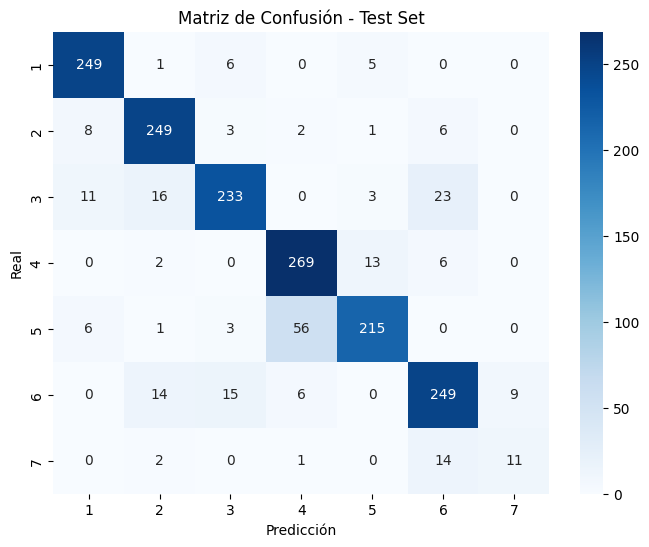

Reporte de clasificación:
              precision    recall  f1-score   support

           1     0.9088    0.9540    0.9308       261
           2     0.8737    0.9257    0.8989       269
           3     0.8962    0.8147    0.8535       286
           4     0.8054    0.9276    0.8622       290
           5     0.9072    0.7651    0.8301       281
           6     0.8356    0.8498    0.8426       293
           7     0.5500    0.3929    0.4583        28

    accuracy                         0.8636      1708
   macro avg     0.8252    0.8043    0.8109      1708
weighted avg     0.8649    0.8636    0.8618      1708



In [ ]:
checkpoint = torch.load(
    modelPath,
    map_location=device,
    weights_only=False
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Checkpoint cargado como diccionario completo.")

else:
    model.load_state_dict(checkpoint)
    print("Checkpoint cargado como state_dict directo.")

model.to(device)
model.eval()

print("Mejor modelo recargado desde:", modelPath)


def getAllPreds(model, dataLoader):
    model.eval()
    yTrue, yPred = [], []

    with torch.no_grad():
        for xBatch, yBatch in dataLoader:
            xBatch = xBatch.to(device)

            outputs = model(xBatch)
            _, predicted = torch.max(outputs, dim=1)

            yTrue.extend(yBatch.cpu().numpy())
            yPred.extend(predicted.cpu().numpy())

    return np.array(yTrue), np.array(yPred)


yTrueTest, yPredTest = getAllPreds(model, loaderTest)

accuracyTest = np.mean(yTrueTest == yPredTest) * 100
maeTest = mean_absolute_error(yTrueTest, yPredTest)
biasTest = np.mean(yPredTest - yTrueTest)
varTest = np.var(yPredTest)

print(f"Accuracy en test set: {accuracyTest:.2f}%")
print(f"MAE (Test): {maeTest:.4f}")
print(f"Bias (Test): {biasTest:.4f}")
print(f"Varianza (Test): {varTest:.4f}")

displayLabels = [indexToLabel[i] for i in range(numClasses)]

cm = confusion_matrix(
    yTrueTest,
    yPredTest,
    labels=list(range(numClasses))
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=displayLabels,
    yticklabels=displayLabels
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Test Set')
plt.show()

print("Reporte de clasificación:")
print(
    classification_report(
        yTrueTest,
        yPredTest,
        labels=list(range(numClasses)),
        target_names=[str(label) for label in displayLabels],
        digits=4,
        zero_division=0
    )
)

In [ ]:
joblib.dump(scaler, scalerPath)

np.savez(
    trainingCurvesPath,
    lossesTrain=np.array(lossesTrain),
    accuraciesVal=np.array(accuraciesVal),
    accuracyTest=np.array([accuracyTest]),
    maeTest=np.array([maeTest]),
    biasTest=np.array([biasTest]),
    varTest=np.array([varTest]),
    originalLabels=np.array(originalLabels)
)

print("Mejor modelo guardado en:", modelPath)
print("Scaler guardado en:", scalerPath)
print("Curvas guardadas en:", trainingCurvesPath)

Mejor modelo guardado en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGBiLSTMModel4.pt
Scaler guardado en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Scalers/scaler4.save
Curvas guardadas en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/training_curves4.npz


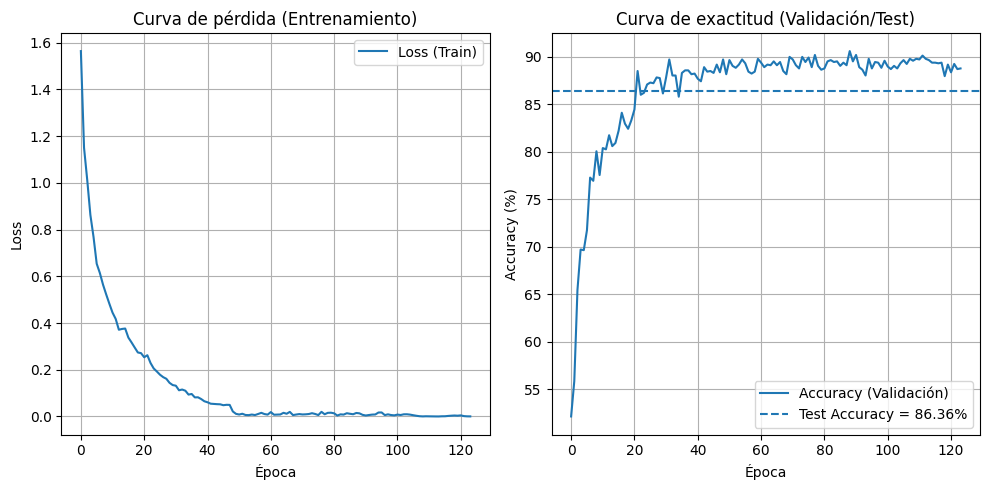

In [ ]:
data = np.load(trainingCurvesPath, allow_pickle=True)

lossesTrain = data["lossesTrain"]
accuraciesVal = data["accuraciesVal"]
accuracyTest = data["accuracyTest"][0]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(lossesTrain, label="Loss (Train)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida (Entrenamiento)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuraciesVal, label="Accuracy (Validación)")
plt.axhline(
    y=accuracyTest,
    linestyle="--",
    label=f"Test Accuracy = {accuracyTest:.2f}%"
)
plt.xlabel("Época")
plt.ylabel("Accuracy (%)")
plt.title("Curva de exactitud (Validación/Test)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()